In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

I0000 00:00:1790672912.848365    9909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790672912.848822    9909 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790672912.880309    9909 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790672913.633107    9909 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape :", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape : (10000, 28, 28)
Testing labels shape: (10000,)


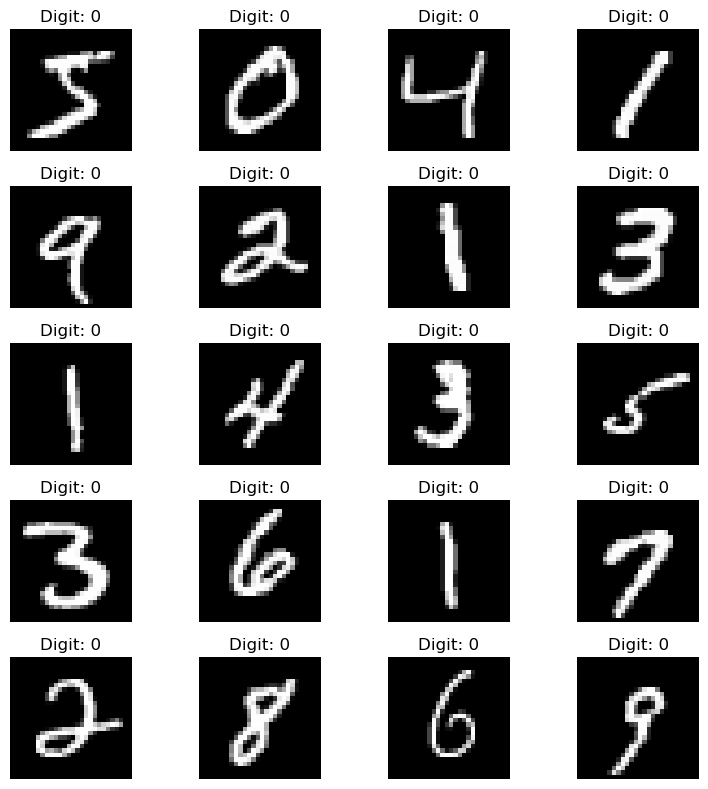

In [4]:
plt.figure(figsize=(8, 8))

for i in range(20):
    plt.subplot(5, 4, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Digit: " + str(np.argmax(y_train[i])))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
x_train = x_train.reshape(x_train.shape[0], 784).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 784).astype("float32")

In [7]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("After preprocessing:")
print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

After preprocessing:
Training data shape: (60000, 784)
Testing data shape : (10000, 784)


In [10]:
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

E0000 00:00:1790673215.418920    9909 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model.compile(
optimizer=SGD(learning_rate=0.03),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [13]:
history = model.fit(
x_train,y_train,
batch_size=128,
epochs=20,
validation_split=0.1,
verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.3007 - val_accuracy: 0.1050 - val_loss: 2.3008
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.3002 - val_accuracy: 0.1050 - val_loss: 2.3007
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2999 - val_accuracy: 0.1050 - val_loss: 2.3007
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2997 - val_accuracy: 0.1050 - val_loss: 2.3002
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2995 - val_accuracy: 0.1050 - val_loss: 2.3000
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2993 - val_accuracy: 0.1050 - val_loss: 2.2999
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2990 - val_accuracy: 0.1050 - val_loss: 2.2997
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1132 - loss: 2.2989 - val_accuracy: 0.

In [14]:
test_loss, test_accuracy = model.evaluate(
x_test,
y_test,
verbose=0
)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 2.2949182987213135
Test Accuracy: 0.11349999904632568


In [15]:
y_probability = model.predict(x_test, verbose=0)

In [16]:
y_pred = np.argmax(y_probability, axis=1)

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[   0  980    0    0    0    0    0    0    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0 1032    0    0    0    0    0    0    0    0]
 [   0 1010    0    0    0    0    0    0    0    0]
 [   0  982    0    0    0    0    0    0    0    0]
 [   0  892    0    0    0    0    0    0    0    0]
 [   0  958    0    0    0    0    0    0    0    0]
 [   0 1028    0    0    0    0    0    0    0    0]
 [   0  974    0    0    0    0    0    0    0    0]
 [   0 1009    0    0    0    0    0    0    0    0]]


In [18]:
print("\nClassification Report:")
print(
classification_report(
y_test,
y_pred,
zero_division=0
)
)


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.11      1.00      0.20      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.00      0.00      0.00       982
           5       0.00      0.00      0.00       892
           6       0.00      0.00      0.00       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.11     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.11      0.02     10000



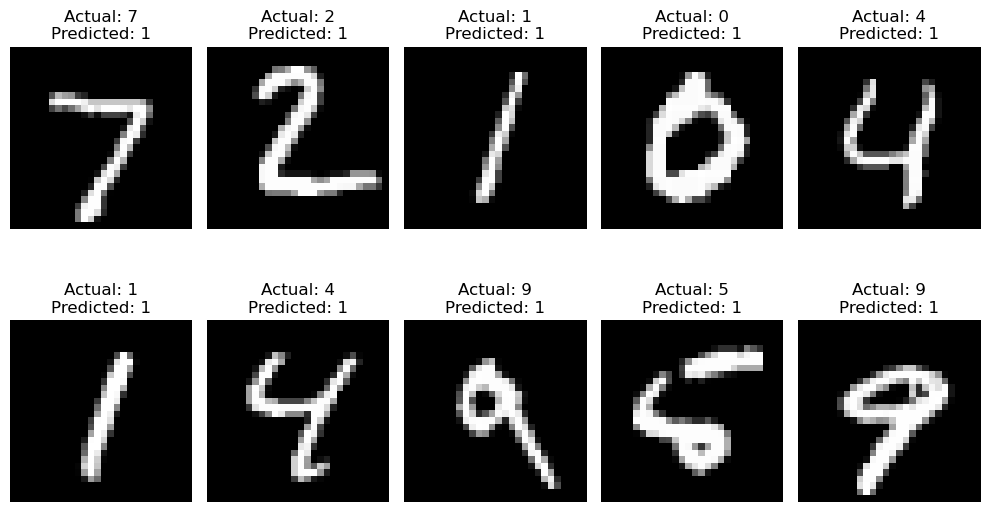

In [19]:
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    image = x_test[i].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(y_pred[i])
    )
    plt.axis("off")

plt.tight_layout()
plt.show()